In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import qutip as qt

In [10]:
N = 20  # Fock space dimention

# Inicial states of the hilbert space
psi_plus  = qt.coherent(N, 1.0)   #|+alpha>
psi_minus = qt.coherent(N, -1.0)  #  |-alpha>


beta = 1.0    #beta=1 (in alpha units, so it's the same as summing alpha)
D = qt.displace(N, beta) #Displacement operator 

state0_shifted = D * psi_minus  # Applying the displacement operator, getting the vaccum state |0>
state1_shifted = D * psi_plus   # |2.0>

n_op = qt.num(N) #number operator

mean_value_minus = qt.expect(n_op, state0_shifted)   #expected value for each state
mean_value_plus  = qt.expect(n_op, state1_shifted)

n = np.arange(0, 10)
P_n_given_bit0 = poisson.pmf(n, mean_value_minus) #Poisson distribution
P_n_given_bit1 = poisson.pmf(n, mean_value_plus)

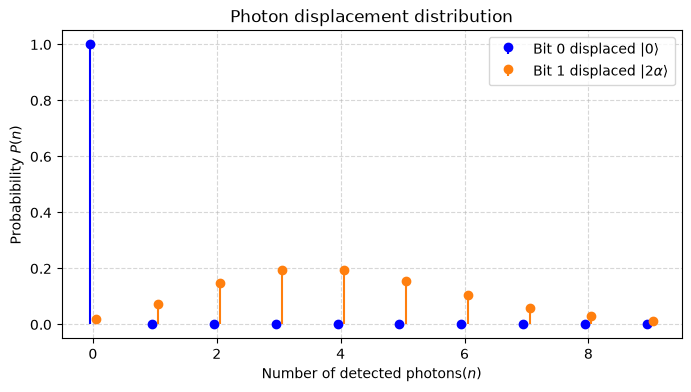

In [13]:
plt.figure(figsize=(8, 4))
plt.stem(n - 0.05, P_n_given_bit0, linefmt='b-', markerfmt='bo', basefmt=" ", label=r'Bit 0 displaced $|0\rangle$')  #Bit 0 - blue 
plt.stem(n + 0.05, P_n_given_bit1, linefmt='C1-', markerfmt='C1o', basefmt=" ", label=r'Bit 1 displaced $|2\alpha\rangle$') #Bit 1 - orange

plt.xlabel('Number of detected photons($n$)')
plt.ylabel('Probabibility $P(n)$')
plt.title(f'Photon displacement distribution')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()